In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\user\Downloads\archive (8)\spotify-track-genre-classification-challenge\train.csv")
df

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,41996,7hUhmkALyQ8SX9mJs5XI3D,Love and Rockets,Love and Rockets,Motorcycle,22.0,211533,false,0.305,0.8490,...,-10.795,1.0,0.0549,0.000058,0.056700,0.4640,0.3200,141.793,4.0,goth
1,76471,5x59U89ZnjZXuNAAlc8X1u,NaN,NaN,"Addio del passato - From ""La traviata""",22.0,196000,FAlSE,NaN,0.1900,...,-12.030,0.0,0.0370,0.930000,0.000356,0.0834,0.1330,83.685,4.0,opera
2,54809,70Vng5jLzoJLmeLu3ayBQq,Susumu Yokota,Symbol,Purple Rose Minuet,37.0,216506,false,0.583,0.5090,...,-9.661,1.0,2.1000,0.777000,0.202000,0.1150,0.5440,90.459,-1.0,idm
3,16326,1cRfzLJapgtwJ61xszs37b,Franz Liszt;YUNDI,Relajación y siestas,"Liebeslied (Widmung), S. 566",0.0,218346,NaN,0.163,0.0368,...,-23.149,1.0,0.0472,0.991000,0.899000,0.1070,0.0387,69.442,3.0,classical
4,109799,47d5lYjbiMy0EdMRV8lRou,Scooter,Scooter Forever,The Darkside,27.0,173160,falSE,0.647,0.9210,...,-7.294,1.0,NaN,0.000939,0.371000,0.1310,0.1710,137.981,4.0,techno
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84795,10401,2C2VP1aEudfYRt5FaM3xSc,The Prodigy,NaN,Stand Up,6.0,330093,FAlSE,0.570,0.9600,...,-7.181,1.0,0.0416,0.003520,0.917000,0.2990,0.2950,100.009,4.0,breakbeat
84796,68714,4srcMdbm2qzVG98tJajHxp,NaN,Pantysito,Pantysito,82.0,240413,NaN,0.830,0.7390,...,-5.395,0.0,0.0627,0.136000,0.000002,0.1620,0.6310,97.993,4.0,latino
84797,29882,0GY4AXqzFomDzUGtoSXB3e,MitiS;Danni Carra,Lost,Without Me (feat. Danni Carra),42.0,266400,False,0.438,0.7160,...,-5.241,1.0,0.0340,0.128000,0.000000,0.2550,0.2270,149.965,4.0,dubstep
84798,76015,1OERvlGpQpPk0fzt9dFDGl,Luciano Pavarotti;National Philharmonic Orches...,Christmas Dinner,"Ave Maria, D. 839 (Arr. Gamley)",-4.0,288346,FalSE,0.214,0.3280,...,-13.545,1.0,0.0377,0.945000,0.000089,0.1050,0.1140,89.521,4.0,opera


In [3]:
df.drop(
    ['track_id','album_name','track_name'],# remove unnsessary data
    axis=1,
    inplace=True
)

In [4]:
df.isnull().sum()

Unnamed: 0              0
artists             11464
popularity             90
duration_ms             0
explicit             7474
danceability         3316
energy               5498
key                     0
loudness             4139
mode                 2783
speechiness          5157
acousticness            0
instrumentalness     3317
liveness              567
valence                 0
tempo                2102
time_signature       1425
track_genre          1853
dtype: int64

In [5]:
num_cols = [
    'danceability',
    'energy',
    'loudness',
    'mode',
    'speechiness',
    'instrumentalness',
    'liveness',
    'tempo',
    'time_signature',
    'popularity',
    
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

In [6]:
df.isnull().sum()

Unnamed: 0              0
artists             11464
popularity              0
duration_ms             0
explicit             7474
danceability            0
energy                  0
key                     0
loudness                0
mode                    0
speechiness             0
acousticness            0
instrumentalness        0
liveness                0
valence                 0
tempo                   0
time_signature          0
track_genre          1853
dtype: int64

In [7]:
df['artists'] = df['artists'].fillna(df['artists'].mode()[0])
df['explicit'] = df['explicit'].fillna('false')

In [8]:
df = df.dropna(subset=['track_genre'])

In [9]:
print(df.isnull().sum().sum())

0


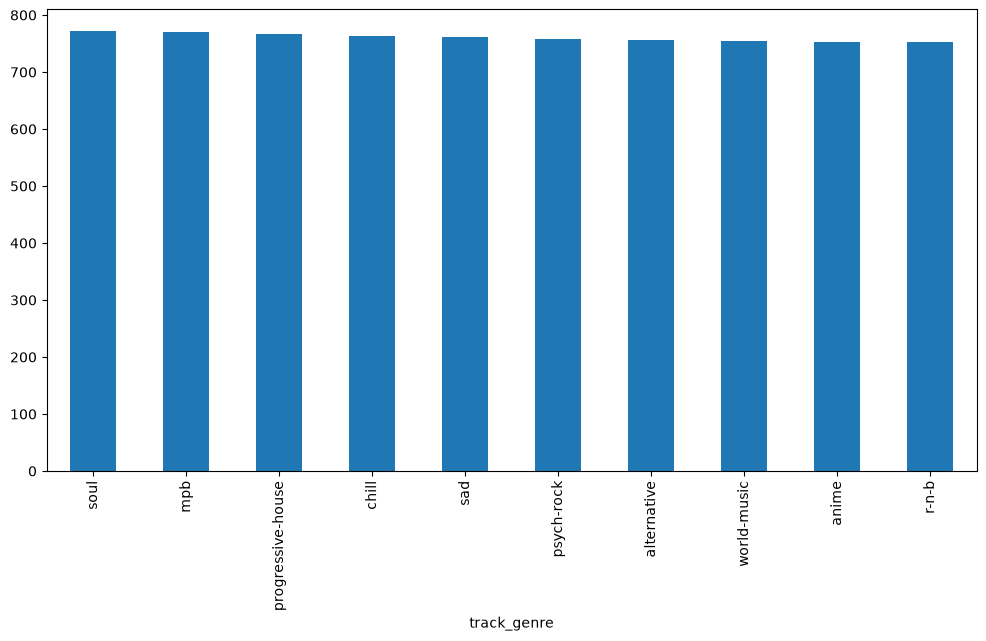

In [37]:
plt.figure(figsize=(12,6))
df['track_genre'].value_counts().head(10).plot(kind='bar')
plt.show()

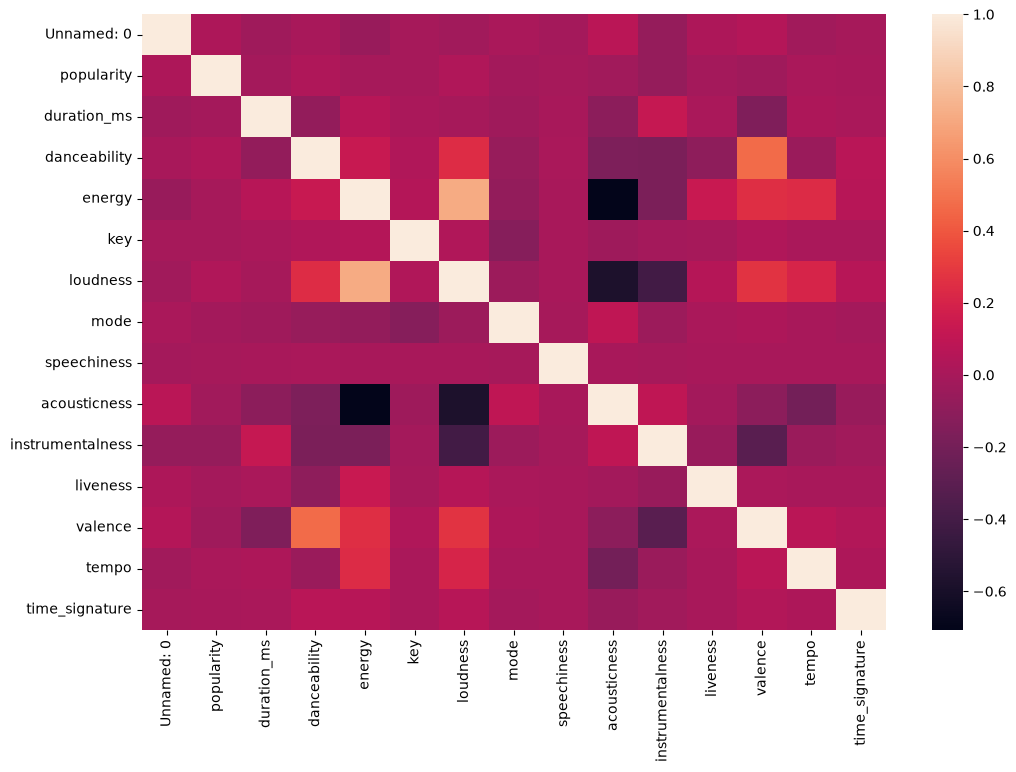

In [11]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),annot=False)
plt.show()

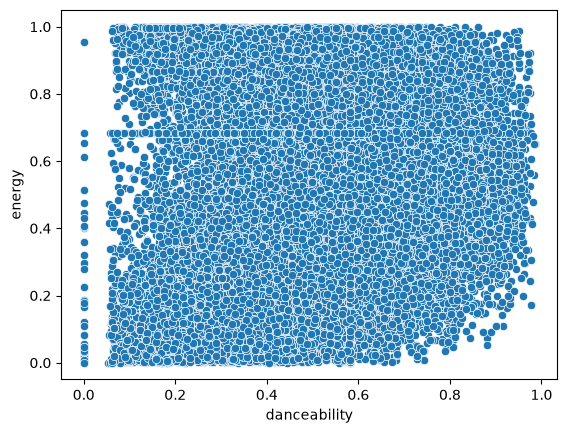

In [12]:
sns.scatterplot(x='danceability',y='energy',data=df)
plt.show()

In [13]:
from sklearn.preprocessing import LabelEncoder

artist_encoder = LabelEncoder()
explicit_encoder = LabelEncoder()

df['artists'] = artist_encoder.fit_transform(df['artists'].astype(str))
df['explicit'] = explicit_encoder.fit_transform(df['explicit'].astype(str))

In [14]:
X = df.drop('track_genre', axis=1)

y = df['track_genre']

In [15]:
print(y.head(10))

0         goth
1        opera
2          idm
3    classical
4       techno
5          pop
6     acoustic
7        study
8        study
9       trance
Name: track_genre, dtype: str


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,                                               #train and split
    y,
    test_size=0.2,
    random_state=42
)

randomforest

In [31]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [30]:
from sklearn.metrics import accuracy_score

y_pred = rf.predict(X_test)

print(
    accuracy_score(
        y_test,
        y_pred
    )
)

0.8730560578661845


In [29]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:",
      accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.5397227245328511


In [18]:
from sklearn.metrics import accuracy_score

y_pred = rf.predict(X_test)

print(
    accuracy_score(
        y_test,
        y_pred
    )
)

0.8730560578661845


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.09758890898131405


C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [32]:
sample = X_test.iloc[[2]]

prediction = rf.predict(sample)

print(prediction[0])

songwriter


In [33]:
print(
    "Actual Genre:",
    y_test.iloc[17]
)

print(
    "Predicted Genre:",
    prediction[0]
)

Actual Genre: latino
Predicted Genre: songwriter


In [34]:
print(df['track_genre'].unique())

<StringArray>
[             'goth',             'opera',               'idm',
         'classical',            'techno',               'pop',
          'acoustic',             'study',            'trance',
 'progressive-house',
 ...
       'world-music',          'mandopop',               'edm',
           'electro',             'anime',             'house',
              'soul',            'grunge',          'afrobeat',
           'turkish']
Length: 114, dtype: str


In [35]:
print('metal' in df['track_genre'].unique())

True


In [36]:
sample = X_test.iloc[[20]]

prediction = rf.predict(sample)

print(prediction[0])

cantopop
